# Import Library

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV

# Data Load

In [2]:
df = pd.read_csv('dataset\heart.csv')
df

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1020,59,1,1,140,221,0,1,164,1,0.0,2,0,2,1
1021,60,1,0,125,258,0,0,141,1,2.8,1,1,3,0
1022,47,1,0,110,275,0,0,118,1,1.0,1,1,2,0
1023,50,0,0,110,254,0,0,159,0,0.0,2,0,2,1


# Data Understanding

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


In [4]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,1025.000000,1025.000000,1025.000000,1025.000000,1025.00000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000
mean,54.434146,0.695610,0.942439,131.611707,246.00000,0.149268,0.529756,149.114146,0.336585,1.071512,1.385366,0.754146,2.323902,0.513171
std,9.072290,0.460373,1.029641,17.516718,51.59251,0.356527,0.527878,23.005724,0.472772,1.175053,0.617755,1.030798,0.620660,0.500070
min,29.000000,0.000000,0.000000,94.000000,126.00000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,0.000000,120.000000,211.00000,0.000000,0.000000,132.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,56.000000,1.000000,1.000000,130.000000,240.00000,0.000000,1.000000,152.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,275.00000,0.000000,1.000000,166.000000,1.000000,1.800000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.00000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [5]:
df.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

In [6]:
df.duplicated().sum()

np.int64(723)

In [7]:
df.drop_duplicates(inplace=True)
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 302 entries, 0 to 878
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       302 non-null    int64  
 1   sex       302 non-null    int64  
 2   cp        302 non-null    int64  
 3   trestbps  302 non-null    int64  
 4   chol      302 non-null    int64  
 5   fbs       302 non-null    int64  
 6   restecg   302 non-null    int64  
 7   thalach   302 non-null    int64  
 8   exang     302 non-null    int64  
 9   oldpeak   302 non-null    float64
 10  slope     302 non-null    int64  
 11  ca        302 non-null    int64  
 12  thal      302 non-null    int64  
 13  target    302 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 35.4 KB


### Add Data

In [8]:
df2 = pd.read_csv('dataset\heart_statlog_cleveland_hungary_final.csv')
df2

,age,sex,chest pain type,resting bp s,cholesterol,fasting blood sugar,resting ecg,max heart rate,exercise angina,oldpeak,ST slope,target
0,40,1,2,140,289,0,0,172,0,0.0,1,0
1,49,0,3,160,180,0,0,156,0,1.0,2,1
2,37,1,2,130,283,0,1,98,0,0.0,1,0
3,48,0,4,138,214,0,0,108,1,1.5,2,1
4,54,1,3,150,195,0,0,122,0,0.0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...
1185,45,1,1,110,264,0,0,132,0,1.2,2,1
1186,68,1,4,144,193,1,0,141,0,3.4,2,1
1187,57,1,4,130,131,0,0,115,1,1.2,2,1
1188,57,0,2,130,236,0,2,174,0,0.0,2,1


In [9]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1190 entries, 0 to 1189
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   age                  1190 non-null   int64  
 1   sex                  1190 non-null   int64  
 2   chest pain type      1190 non-null   int64  
 3   resting bp s         1190 non-null   int64  
 4   cholesterol          1190 non-null   int64  
 5   fasting blood sugar  1190 non-null   int64  
 6   resting ecg          1190 non-null   int64  
 7   max heart rate       1190 non-null   int64  
 8   exercise angina      1190 non-null   int64  
 9   oldpeak              1190 non-null   float64
 10  ST slope             1190 non-null   int64  
 11  target               1190 non-null   int64  
dtypes: float64(1), int64(11)
memory usage: 111.7 KB


In [10]:
df2.duplicated().sum()

np.int64(272)

In [11]:
df2.drop_duplicates(inplace=True)
df2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 918 entries, 0 to 1189
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   age                  918 non-null    int64  
 1   sex                  918 non-null    int64  
 2   chest pain type      918 non-null    int64  
 3   resting bp s         918 non-null    int64  
 4   cholesterol          918 non-null    int64  
 5   fasting blood sugar  918 non-null    int64  
 6   resting ecg          918 non-null    int64  
 7   max heart rate       918 non-null    int64  
 8   exercise angina      918 non-null    int64  
 9   oldpeak              918 non-null    float64
 10  ST slope             918 non-null    int64  
 11  target               918 non-null    int64  
dtypes: float64(1), int64(11)
memory usage: 93.2 KB


rename df2

In [12]:
df2 = df2.rename(columns={
    'chest pain type': 'cp',
    'resting bp s': 'trestbps',
    'cholesterol': 'chol',
    'fasting blood sugar': 'fbs',
    'resting ecg': 'restecg',
    'max heart rate': 'thalach',
    'exercise angina': 'exang',
    'ST slope': 'slope'
})
df2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 918 entries, 0 to 1189
Data columns (total 12 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       918 non-null    int64  
 1   sex       918 non-null    int64  
 2   cp        918 non-null    int64  
 3   trestbps  918 non-null    int64  
 4   chol      918 non-null    int64  
 5   fbs       918 non-null    int64  
 6   restecg   918 non-null    int64  
 7   thalach   918 non-null    int64  
 8   exang     918 non-null    int64  
 9   oldpeak   918 non-null    float64
 10  slope     918 non-null    int64  
 11  target    918 non-null    int64  
dtypes: float64(1), int64(11)
memory usage: 93.2 KB


In [13]:
df2.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,target
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,0.789760,3.251634,132.396514,198.799564,0.233115,0.603486,136.809368,0.404139,0.887364,1.636166,0.553377
std,9.432617,0.407701,0.931031,18.514154,109.384145,0.423046,0.805968,25.460334,0.490992,1.066570,0.609341,0.497414
min,28.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,60.000000,0.000000,-2.600000,0.000000,0.000000
25%,47.000000,1.000000,3.000000,120.000000,173.250000,0.000000,0.000000,120.000000,0.000000,0.000000,1.000000,0.000000
50%,54.000000,1.000000,4.000000,130.000000,223.000000,0.000000,0.000000,138.000000,0.000000,0.600000,2.000000,1.000000
75%,60.000000,1.000000,4.000000,140.000000,267.000000,0.000000,1.000000,156.000000,1.000000,1.500000,2.000000,1.000000
max,77.000000,1.000000,4.000000,200.000000,603.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,1.000000


In [14]:
common_columns = ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs',
                  'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'target']

df_filtered = df[common_columns]
df2_filtered = df2[common_columns]

df_combined = pd.concat([df_filtered, df2_filtered], ignore_index=True)
df_combined.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1220 entries, 0 to 1219
Data columns (total 12 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1220 non-null   int64  
 1   sex       1220 non-null   int64  
 2   cp        1220 non-null   int64  
 3   trestbps  1220 non-null   int64  
 4   chol      1220 non-null   int64  
 5   fbs       1220 non-null   int64  
 6   restecg   1220 non-null   int64  
 7   thalach   1220 non-null   int64  
 8   exang     1220 non-null   int64  
 9   oldpeak   1220 non-null   float64
 10  slope     1220 non-null   int64  
 11  target    1220 non-null   int64  
dtypes: float64(1), int64(11)
memory usage: 114.5 KB


gabungkan data dengan fitur yg terdapat pada df2

## Exploratory Data Analysis

### Distribusi fitur

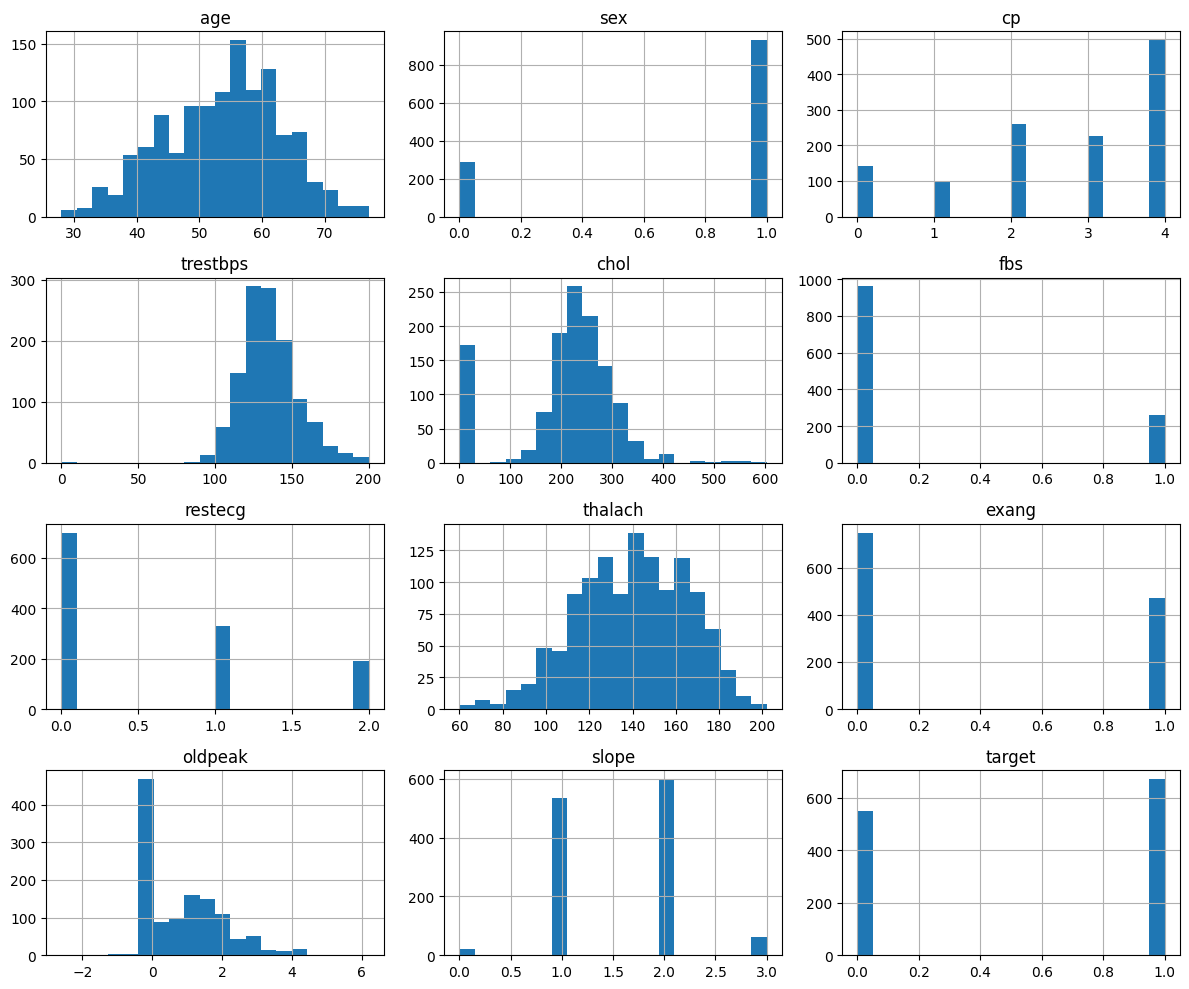

In [15]:
df_combined.hist(figsize=(12, 10), bins=20)
plt.tight_layout()
plt.show()

Gambar di atas menunjukkan distribusi dari setiap fitur dalam dataset heart.csv. Tujuan visualisasi ini adalah untuk memahami karakteristik data dan melihat pola atau anomali sebelum dilakukan proses modeling lebih lanjut.

Berikut beberapa insight penting dari histogram tiap fitur:

- age: Usia pasien berkisar antara 30 hingga 77 tahun, dengan mayoritas berada di rentang 50–60 tahun.

- sex: Sebagian besar pasien adalah laki-laki (1), menunjukkan ketimpangan distribusi gender dalam dataset.

- cp (chest pain type): Kategori 0 dan 4 mendominasi tipe nyeri dada, menunjukkan dua tipe tersebut paling umum.

- trestbps (resting blood pressure): Sebagian besar tekanan darah istirahat berada di antara 110–140 mmHg.

- chol (cholesterol): Kadar kolesterol memiliki distribusi miring ke kanan (right-skewed), dengan sebagian besar pasien memiliki kadar antara 200–300 mg/dL.

- fbs (fasting blood sugar > 120 mg/dL): Mayoritas pasien memiliki kadar gula darah puasa normal (0).

- restecg (resting ECG results): Kategori 0 mendominasi, menunjukkan hasil EKG yang normal lebih sering terjadi.

- thalach (maximum heart rate achieved): Detak jantung maksimum bervariasi, namun paling sering berada di rentang 130–170 bpm.

- exang (exercise-induced angina): Sebagian besar pasien tidak mengalami nyeri dada akibat olahraga.

- oldpeak (ST depression): Mayoritas pasien memiliki nilai oldpeak mendekati 0, meskipun ada outlier hingga nilai 6.

- slope (slope of the ST segment): Kategori 1 (kemiringan rata-rata) paling umum, disusul kategori 2 dan 0.

- target: Label target menunjukkan bahwa data relatif seimbang, dengan sedikit lebih banyak pasien yang terdiagnosis penyakit jantung (1) dibandingkan yang tidak (0).

### Target analysis

<Axes: xlabel='target', ylabel='count'>

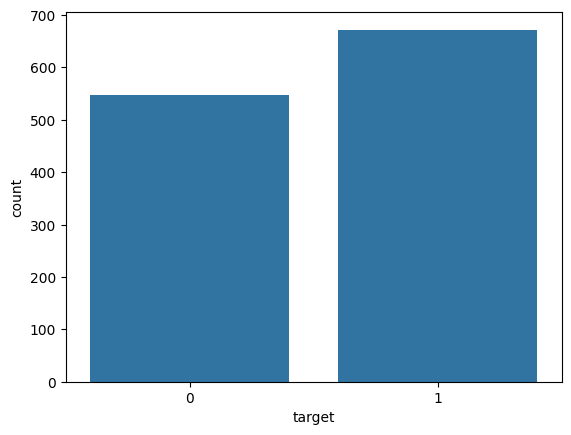

In [16]:
sns.countplot(x='target', data=df_combined)

In [17]:
df_combined['target'].value_counts(normalize=True)

target
1    0.55082
0    0.44918
Name: proportion, dtype: float64

Fitur target menunjukkan kondisi jantung pasien, dengan nilai 1 berarti memiliki penyakit jantung dan 0 berarti tidak.

Distribusi data:

- 1 (sakit): 55,1%

- 0 (tidak sakit): 44,9%

### Relasi antar fitur

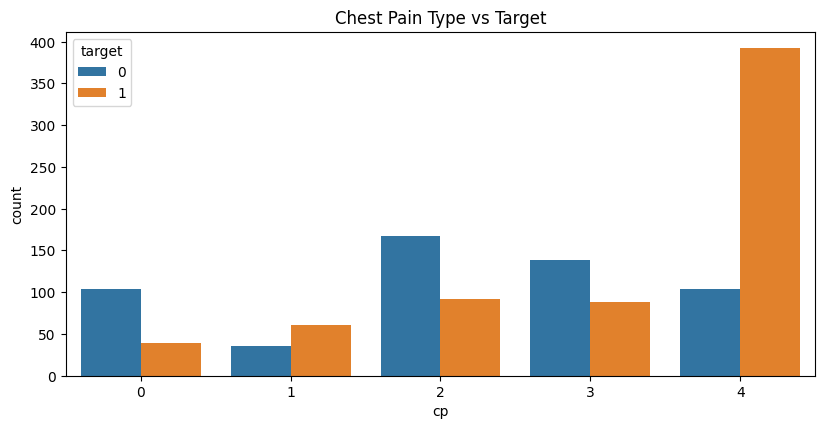

In [18]:
plt.figure(figsize=(16, 12))

# 1. Chest Pain Type vs Target
plt.subplot(3, 2, 1)
sns.countplot(x='cp', hue='target', data=df_combined)
plt.title('Chest Pain Type vs Target')

plt.tight_layout()
plt.show()

Grafik menunjukkan distribusi jenis nyeri dada (cp) terhadap kondisi jantung (target):

- cp = 4 (asymptomatic) paling sering dikaitkan dengan pasien yang memiliki penyakit jantung (target = 1).

- cp = 2 dan 3 cenderung lebih umum pada pasien tanpa penyakit jantung (target = 0).

- Pasien dengan cp = 1 lebih banyak memiliki penyakit jantung dibanding yang tidak.

Kesimpulan: Jenis nyeri dada memiliki korelasi kuat terhadap kondisi jantung, khususnya cp = 4 sebagai indikator signifikan penyakit jantung.

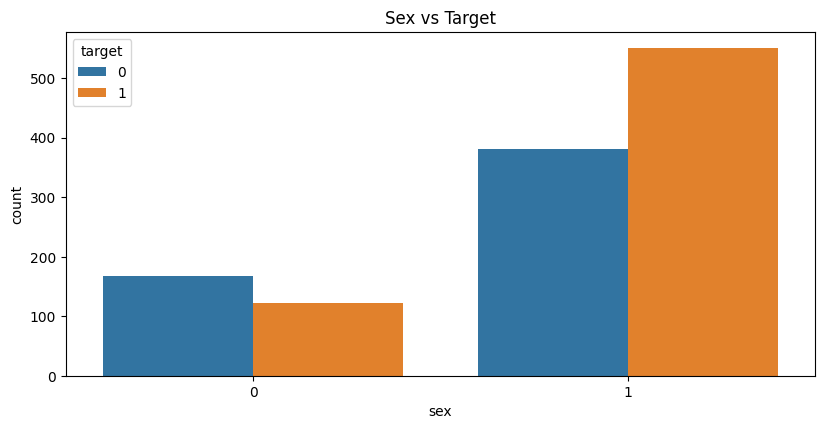

In [19]:
# 2. Sex vs Target
plt.figure(figsize=(16, 12))
plt.subplot(3, 2, 2)
sns.countplot(x='sex', hue='target', data=df_combined)
plt.title('Sex vs Target')

plt.tight_layout()
plt.show()

- sex = 1 (laki-laki) memiliki jumlah kasus penyakit jantung (target = 1) yang lebih tinggi dibanding yang tidak sakit.

- sex = 0 (perempuan) justru lebih banyak yang tidak menderita penyakit jantung.

Kesimpulan: Laki-laki cenderung memiliki risiko lebih tinggi terhadap penyakit jantung dibanding perempuan dalam dataset ini.

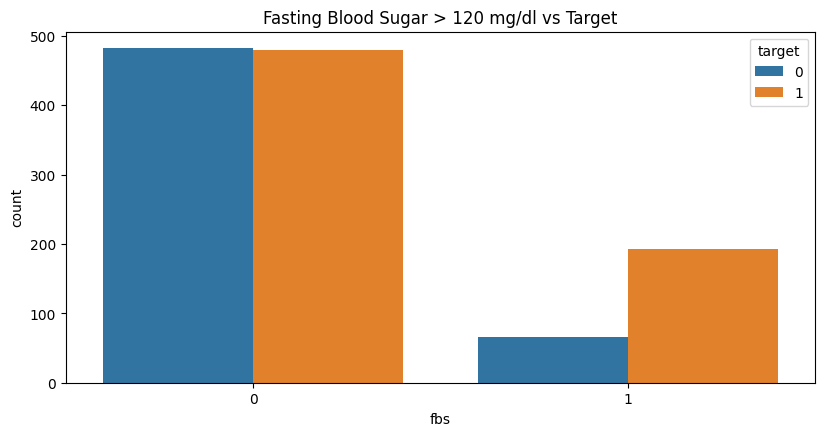

In [20]:
# 3. Fasting Blood Sugar vs Target
plt.figure(figsize=(16, 12))
plt.subplot(3, 2, 3)
sns.countplot(x='fbs', hue='target', data=df_combined)
plt.title('Fasting Blood Sugar > 120 mg/dl vs Target')

plt.tight_layout()
plt.show()

- Pada fbs = 0 (gula darah ≤ 120 mg/dl), distribusi antara penderita dan non-penderita penyakit jantung hampir seimbang.

- Pada fbs = 1 (gula darah > 120 mg/dl), mayoritas mengalami penyakit jantung (target = 1).

Kesimpulan: Gula darah puasa tinggi berpotensi berkorelasi dengan peningkatan risiko penyakit jantung, meskipun jumlah kasusnya relatif kecil.

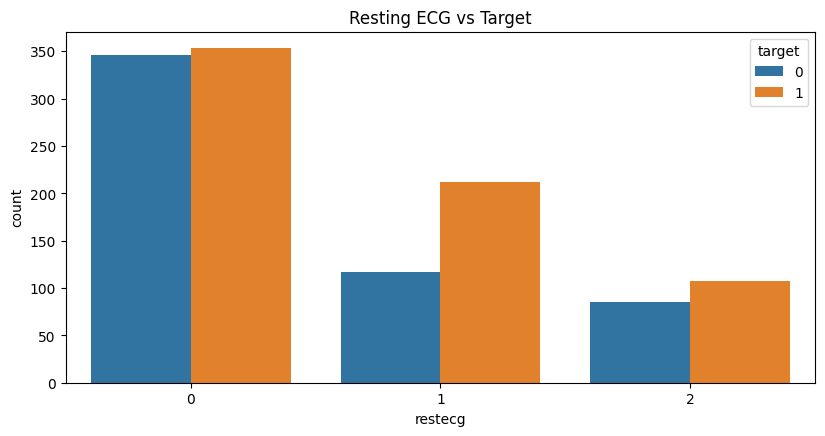

In [21]:
# 4. Resting ECG vs Target
plt.figure(figsize=(16, 12))
plt.subplot(3, 2, 4)
sns.countplot(x='restecg', hue='target', data=df_combined)
plt.title('Resting ECG vs Target')

plt.tight_layout()
plt.show()

- Pada restecg = 0 (hasil normal), jumlah penderita dan non-penderita hampir seimbang.

- Pada restecg = 1 (abnormalitas ST-T), lebih banyak yang menderita penyakit jantung.

- Pada restecg = 2 (hipertrofi ventrikel kiri), penderita juga sedikit lebih banyak.

Kesimpulan: Abnormalitas hasil ECG, terutama kategori 1 dan 2, cenderung terkait dengan peningkatan risiko penyakit jantung.

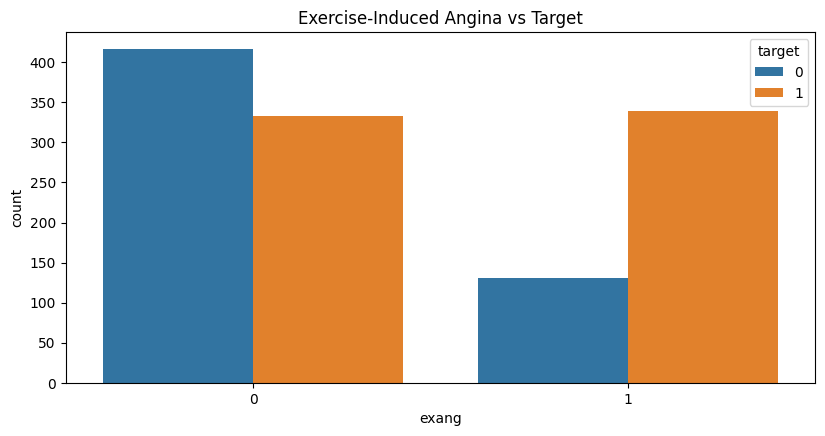

In [22]:
# 5. Exercise-Induced Angina vs Target
plt.figure(figsize=(16, 12))
plt.subplot(3, 2, 5)
sns.countplot(x='exang', hue='target', data=df_combined)
plt.title('Exercise-Induced Angina vs Target')

plt.tight_layout()
plt.show()

- Pada exang = 0 (tidak mengalami angina saat olahraga), jumlah penderita dan non-penderita cukup seimbang.

- Pada exang = 1 (mengalami angina saat olahraga), mayoritas adalah penderita penyakit jantung.

Kesimpulan: Angina yang dipicu oleh aktivitas fisik berkorelasi kuat dengan penyakit jantung.

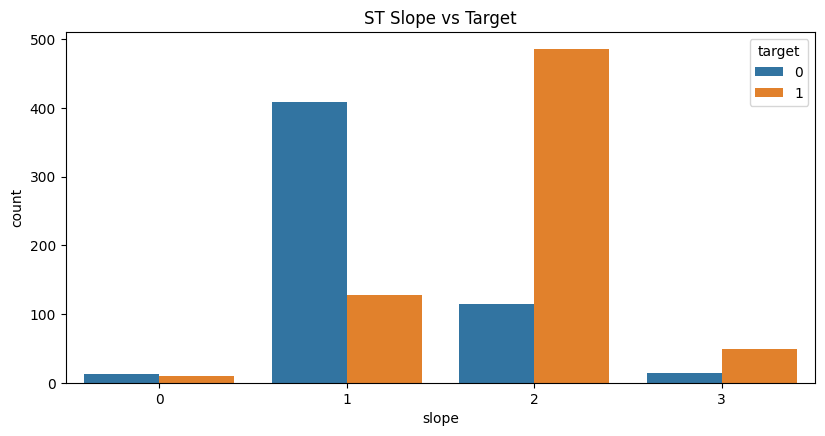

In [23]:
# 6. ST Slope vs Target
plt.figure(figsize=(16, 12))
plt.subplot(3, 2, 6)
sns.countplot(x='slope', hue='target', data=df_combined)
plt.title('ST Slope vs Target')

plt.tight_layout()
plt.show()

# Data Preparation

In [24]:
df.drop_duplicates(inplace=True)
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 302 entries, 0 to 878
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       302 non-null    int64  
 1   sex       302 non-null    int64  
 2   cp        302 non-null    int64  
 3   trestbps  302 non-null    int64  
 4   chol      302 non-null    int64  
 5   fbs       302 non-null    int64  
 6   restecg   302 non-null    int64  
 7   thalach   302 non-null    int64  
 8   exang     302 non-null    int64  
 9   oldpeak   302 non-null    float64
 10  slope     302 non-null    int64  
 11  ca        302 non-null    int64  
 12  thal      302 non-null    int64  
 13  target    302 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 35.4 KB


Karena jumlah data hanya 302 entri, yang relatif kecil untuk proses pelatihan model machine learning, maka dilakukan pencarian dan penambahan data tambahan dari sumber lain agar analisis dan model prediksi menjadi lebih kuat dan representatif.

### Cleaning Data

In [25]:
df_combined.duplicated().sum()

np.int64(0)

In [26]:
df_combined.drop_duplicates(inplace=True)
df_combined.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1220 entries, 0 to 1219
Data columns (total 12 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1220 non-null   int64  
 1   sex       1220 non-null   int64  
 2   cp        1220 non-null   int64  
 3   trestbps  1220 non-null   int64  
 4   chol      1220 non-null   int64  
 5   fbs       1220 non-null   int64  
 6   restecg   1220 non-null   int64  
 7   thalach   1220 non-null   int64  
 8   exang     1220 non-null   int64  
 9   oldpeak   1220 non-null   float64
 10  slope     1220 non-null   int64  
 11  target    1220 non-null   int64  
dtypes: float64(1), int64(11)
memory usage: 114.5 KB


In [27]:
df_combined.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,target
count,1220.000000,1220.000000,1220.000000,1220.000000,1220.000000,1220.000000,1220.000000,1220.000000,1220.000000,1220.000000,1220.000000,1220.000000
mean,53.736066,0.763115,2.685246,132.200000,210.607377,0.212295,0.584426,139.968033,0.385246,0.925902,1.577049,0.550820
std,9.343461,0.425346,1.375138,18.279509,100.430014,0.409100,0.747050,25.446332,0.486853,1.092409,0.619453,0.497615
min,28.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,60.000000,0.000000,-2.600000,0.000000,0.000000
25%,47.000000,1.000000,2.000000,120.000000,188.000000,0.000000,0.000000,122.000000,0.000000,0.000000,1.000000,0.000000
50%,54.000000,1.000000,3.000000,130.000000,228.000000,0.000000,0.000000,141.000000,0.000000,0.600000,2.000000,1.000000
75%,60.000000,1.000000,4.000000,140.000000,269.000000,0.000000,1.000000,160.000000,1.000000,1.600000,2.000000,1.000000
max,77.000000,1.000000,4.000000,200.000000,603.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,1.000000


In [28]:

Q1 = df_combined[['oldpeak', 'chol', 'trestbps']].quantile(0.25)
Q3 = df_combined[['oldpeak', 'chol', 'trestbps']].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df_combined = df_combined[
    (df_combined['chol'] >= lower_bound['chol']) & (df_combined['chol'] <= upper_bound['chol']) &
    (df_combined['oldpeak'] >= lower_bound['oldpeak']) & (df_combined['oldpeak'] <= upper_bound['oldpeak']) &
    (df_combined['trestbps'] >= lower_bound['trestbps']) & (df_combined['trestbps'] <= upper_bound['trestbps'])
]



In [29]:
df_combined.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,target
count,989.000000,989.000000,989.000000,989.000000,989.000000,989.000000,989.000000,989.000000,989.000000,989.000000,989.000000,989.000000
mean,53.166835,0.747219,2.525784,131.071790,239.867543,0.156724,0.601618,143.104146,0.362993,0.886047,1.527806,0.493428
std,9.470253,0.434826,1.385506,15.428558,47.968799,0.363724,0.758913,24.451685,0.481106,1.010796,0.597299,0.500210
min,28.000000,0.000000,0.000000,92.000000,85.000000,0.000000,0.000000,71.000000,0.000000,-0.100000,0.000000,0.000000
25%,46.000000,0.000000,2.000000,120.000000,207.000000,0.000000,0.000000,125.000000,0.000000,0.000000,1.000000,0.000000
50%,54.000000,1.000000,3.000000,130.000000,236.000000,0.000000,0.000000,144.000000,0.000000,0.600000,2.000000,0.000000
75%,60.000000,1.000000,4.000000,140.000000,271.000000,0.000000,1.000000,162.000000,1.000000,1.500000,2.000000,1.000000
max,77.000000,1.000000,4.000000,170.000000,388.000000,1.000000,2.000000,202.000000,1.000000,4.000000,3.000000,1.000000


In [30]:
df_combined.info()

<class 'pandas.core.frame.DataFrame'>
Index: 989 entries, 0 to 1219
Data columns (total 12 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       989 non-null    int64  
 1   sex       989 non-null    int64  
 2   cp        989 non-null    int64  
 3   trestbps  989 non-null    int64  
 4   chol      989 non-null    int64  
 5   fbs       989 non-null    int64  
 6   restecg   989 non-null    int64  
 7   thalach   989 non-null    int64  
 8   exang     989 non-null    int64  
 9   oldpeak   989 non-null    float64
 10  slope     989 non-null    int64  
 11  target    989 non-null    int64  
dtypes: float64(1), int64(11)
memory usage: 100.4 KB


dataset yang digunakan adalah heart.csv dan heart_statlog_cleveland_hungary_final.csv dengan total 989 entri dan 11 kolom fitur medis. Data ini diadaptasi dari dataset publik dari Kaggle.

- age: usia pasien

- sex: jenis kelamin (1 = laki-laki, 0 = perempuan)

- cp: jenis nyeri dada (0–4)

- trestbps: tekanan darah saat istirahat (mm Hg)

- chol: kadar kolesterol (mg/dl)

- fbs: gula darah puasa > 120 mg/dl (1 = ya, 0 = tidak)

- restecg: hasil EKG saat istirahat

- thalach: detak jantung maksimum

- exang: nyeri dada akibat latihan (1 = ya)

- oldpeak: depresi ST (numerik)

- slope: kemiringan segmen ST (0–3)

- target: diagnosis akhir (0 = tidak sakit, 1 = ada penyakit jantung)

## Split Dataset

In [31]:
X = df_combined.drop('target', axis=1)
y = df_combined['target']

# Split data into 80% train, 10% validation, and 10% test
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.333, random_state=42, stratify=y_temp)

print("X_train shape:", X_train.shape)
print("X_val shape:", X_val.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_val shape:", y_val.shape)
print("y_test shape:", y_test.shape)

X_train shape: (791, 11)
X_val shape: (132, 11)
X_test shape: (66, 11)
y_train shape: (791,)
y_val shape: (132,)
y_test shape: (66,)


    Pada tahap ini, saya melakukan pembagian dataset menjadi tiga bagian utama yaitu data latih (training), data validasi (validation), dan data uji (testing). Proses ini dilakukan untuk mempersiapkan data sebelum digunakan dalam pelatihan dan evaluasi model machine learning.

Hasil split data menunjukkan bahwa:

- Data latih (X_train) berjumlah 791 sampel dengan 11 fitur, digunakan untuk melatih model agar dapat mempelajari pola dari data.

- Data validasi (X_val) berjumlah 132 sampel, digunakan untuk menguji performa model selama pelatihan dan membantu melakukan tuning parameter agar model tidak overfitting.

- Data uji (X_test) berjumlah 66 sampel, berfungsi sebagai data baru yang tidak terlihat oleh model selama pelatihan, untuk mengevaluasi performa akhir model secara objektif.

- Target variabel (y) juga dibagi sesuai proporsi tersebut.

Tahapan pembagian dataset ini sangat penting untuk memastikan model yang dibangun dapat generalisasi dengan baik terhadap data yang belum pernah dilihat sebelumnya. Dengan adanya data validasi dan testing yang terpisah, proses pelatihan model menjadi lebih terkontrol dan hasil evaluasi model dapat dipercaya sebagai representasi performa nyata saat diaplikasikan ke data sesungguhnya.

## SMOTE data (hanya pada Train)

In [32]:

smote = SMOTE(random_state=42)


X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print(f"Length of X_train after SMOTE: {len(X_train)}")
print(f"Length of y_train after SMOTE: {len(y_train)}")

Length of X_train after SMOTE: 791
Length of y_train after SMOTE: 791


d:\AR2R\machine_learning_terapan\p1\p1env\lib\site-packages\sklearn\base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


Pada tahap ini, saya melakukan proses penyeimbangan data menggunakan metode SMOTE (Synthetic Minority Over-sampling Technique) untuk mengatasi ketidakseimbangan kelas pada dataset. Setelah penerapan SMOTE, dataset yang digunakan memiliki total 1.002 entri dengan 12 fitur, yang meliputi variabel numerik seperti usia (age), tekanan darah istirahat (trestbps), kolesterol (chol), dan fitur target (target).

Dari output informasi struktur data, terlihat bahwa semua kolom memiliki nilai yang lengkap tanpa missing value (non-null count = 1.002 pada setiap kolom). Dataset terdiri dari 11 fitur numerik bertipe integer dan 1 fitur bertipe float (oldpeak). Ukuran memori yang digunakan dataset ini sebesar sekitar 126 KB.

Dengan data yang sudah seimbang ini, model machine learning nantinya dapat dilatih tanpa bias terhadap kelas mayoritas, sehingga diharapkan hasil prediksi menjadi lebih akurat dan fair.

## Feature Scaling

In [33]:
scaler = StandardScaler()

# salin data supaya tidak mengubah asli
X_train_scaled = X_train_smote.copy()
X_val_scaled = X_val.copy()
X_test_scaled = X_test.copy()       

# scaling hanya beberapa fitur 
fitur_scaling = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

X_train_scaled[fitur_scaling] = scaler.fit_transform(X_train_smote[fitur_scaling])
X_val_scaled[fitur_scaling] = scaler.transform(X_val[fitur_scaling])
X_test_scaled[fitur_scaling] = scaler.transform(X_test[fitur_scaling])


Pada tahap ini, dilakukan proses scaling menggunakan StandardScaler untuk menormalkan beberapa fitur numerik terpilih yakni usia (age), tekanan darah (trestbps), kolesterol (chol), detak jantung maksimum (thalach), dan perubahan ST (oldpeak). Scaling hanya diterapkan pada fitur-fitur tersebut karena memiliki rentang nilai yang berbeda jauh dibanding fitur kategori lainnya.

Proses ini penting agar setiap fitur memiliki skala yang seragam dengan rata-rata nol dan standar deviasi satu, sehingga model machine learning dapat belajar lebih efektif tanpa bias akibat perbedaan skala fitur. Scaling juga membantu mempercepat konvergensi algoritma dan meningkatkan performa model.

# Modeling

## Model 1 Random Forest

In [34]:
param_rf = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

rf_model = RandomForestClassifier(random_state=42)
random_search_rf = RandomizedSearchCV(estimator=rf_model, param_distributions=param_rf, n_iter=60, cv=5, scoring='accuracy', random_state=42, verbose=1)
random_search_rf.fit(X_train_scaled, y_train_smote)

best_params_rf = random_search_rf.best_params_
best_rf_model = random_search_rf.best_estimator_

y_pred_rf = best_rf_model.predict(X_val_scaled)

print("=====Result=====")
print("Accuracy : ", accuracy_score(y_val,y_pred_rf))
print("====Classification Report====")
target_names = ['Tidak Sakit Jantung', 'Sakit Jantung']
print(classification_report(y_val,y_pred_rf, target_names=target_names))
print("====Conf Matrix====")
print(confusion_matrix(y_val, y_pred_rf,))
print("====Parameters Used====")
print(best_params_rf)

Fitting 5 folds for each of 60 candidates, totalling 300 fits
=====Result=====
Accuracy :  0.8257575757575758
====Classification Report====
                     precision    recall  f1-score   support

Tidak Sakit Jantung       0.82      0.84      0.83        67
      Sakit Jantung       0.83      0.82      0.82        65

           accuracy                           0.83       132
          macro avg       0.83      0.83      0.83       132
       weighted avg       0.83      0.83      0.83       132

====Conf Matrix====
[[56 11]
 [12 53]]
====Parameters Used====
{'n_estimators': 300, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_depth': 20}


Model yang diuji menggunakan 5-fold cross-validation dengan 60 kombinasi hyperparameter menghasilkan akurasi sebesar 82,6%. Dari classification report, model mampu mengklasifikasikan kelas "Tidak Sakit Jantung" dengan precision 82% dan recall 84%, serta kelas "Sakit Jantung" dengan precision 83% dan recall 82%. Nilai f1-score untuk kedua kelas berada di kisaran 0,82–0,83, menunjukkan performa yang seimbang.

Confusion matrix memperlihatkan bahwa model melakukan 11 kesalahan prediksi pada kelas negatif dan 12 kesalahan pada kelas positif. Hyperparameter terbaik yang diperoleh adalah n_estimators=300, min_samples_split=2, min_samples_leaf=1, dan max_depth=20.

Proses improvement dilakukan dengan melakukan hyperparameter tuning untuk menemukan kombinasi parameter yang optimal, meningkatkan performa model dibanding pengaturan default. Jika menggunakan beberapa algoritma, model ini dipilih sebagai solusi terbaik karena memberikan keseimbangan antara akurasi, precision, dan recall yang baik, serta stabilitas hasil pada validasi silang.

## Model 2 XGBoost

In [35]:
param_xgb = {
    'n_estimators': [100, 200, 300, 400],
    'max_depth': [7, 8, 9, 10, 15],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.8, 0.9, 1.0],
    'colsample_bytree': [0.8, 0.9, 1.0]
}

xgb_model = XGBClassifier(random_state=42)
random_search_xgb = RandomizedSearchCV(estimator=xgb_model, param_distributions=param_xgb, n_iter=20, cv=5, scoring='accuracy', random_state=42, verbose=1)
random_search_xgb.fit(X_train_scaled, y_train_smote)

best_params_xgb = random_search_xgb.best_params_
best_xgb_model = random_search_xgb.best_estimator_

y_pred_xgb = best_xgb_model.predict(X_val_scaled)

print("=====Result=====")
print("Accuracy : ", accuracy_score(y_val,y_pred_xgb))
print("====Classification Report====")  
target_names = ['Tidak Sakit Jantung', 'Sakit Jantung']
print(classification_report(y_val, y_pred_xgb, target_names=target_names))
print("====Conf Matrix====")
print(confusion_matrix(y_val, y_pred_xgb))
print("====Parameters Used====")
print(best_params_xgb)

Fitting 5 folds for each of 20 candidates, totalling 100 fits
=====Result=====
Accuracy :  0.8333333333333334
====Classification Report====
                     precision    recall  f1-score   support

Tidak Sakit Jantung       0.83      0.85      0.84        67
      Sakit Jantung       0.84      0.82      0.83        65

           accuracy                           0.83       132
          macro avg       0.83      0.83      0.83       132
       weighted avg       0.83      0.83      0.83       132

====Conf Matrix====
[[57 10]
 [12 53]]
====Parameters Used====
{'subsample': 0.9, 'n_estimators': 100, 'max_depth': 15, 'learning_rate': 0.01, 'colsample_bytree': 0.9}


Model XGBoost diuji menggunakan 5-fold cross-validation dengan 20 kombinasi hyperparameter, menghasilkan akurasi sebesar 83,3%. Dari classification report, model menunjukkan kemampuan klasifikasi yang seimbang, dengan precision 83% dan recall 85% untuk kelas "Tidak Sakit Jantung", serta precision 84% dan recall 82% untuk kelas "Sakit Jantung". Nilai f1-score untuk kedua kelas berada di kisaran 0,83–0,84, mencerminkan performa yang solid dan konsisten.

Confusion matrix memperlihatkan bahwa model melakukan 10 kesalahan prediksi pada kelas negatif dan 12 kesalahan pada kelas positif. Hyperparameter terbaik yang diperoleh adalah n_estimators=100, max_depth=15, learning_rate=0.01, subsample=0.9, dan colsample_bytree=0.9.

Proses tuning dilakukan untuk menghindari overfitting sekaligus meningkatkan generalisasi model. Dibandingkan dengan model sebelumnya, model ini menunjukkan performa yang sedikit lebih baik dan menjadi kandidat kuat sebagai solusi utama karena memberikan keseimbangan antara akurasi, presisi, dan recall yang optimal.

# Evaluation

## Model 1 Evaluation

In [36]:
y_test_rf = best_rf_model.predict(X_test_scaled)

print("=====Result Random Forest=====")
print("Accuracy : ", accuracy_score(y_test,y_test_rf))
print("====Classification Report====")
target_names = ['Tidak Sakit Jantung', 'Sakit Jantung']
print(classification_report(y_test, y_test_rf, target_names=target_names))
print("====Conf Matrix====")
print(confusion_matrix(y_test, y_test_rf))

=====Result Random Forest=====
Accuracy :  0.8333333333333334
====Classification Report====
                     precision    recall  f1-score   support

Tidak Sakit Jantung       0.87      0.79      0.83        33
      Sakit Jantung       0.81      0.88      0.84        33

           accuracy                           0.83        66
          macro avg       0.84      0.83      0.83        66
       weighted avg       0.84      0.83      0.83        66

====Conf Matrix====
[[26  7]
 [ 4 29]]


In [37]:

importances = best_rf_model.feature_importances_

# Buat DataFrame untuk visualisasi
feature_names = X_train.columns 
feat_importances = pd.Series(importances, index=feature_names)

# Urutkan dari penting ke tidak
feat_importances = feat_importances.sort_values(ascending=False)

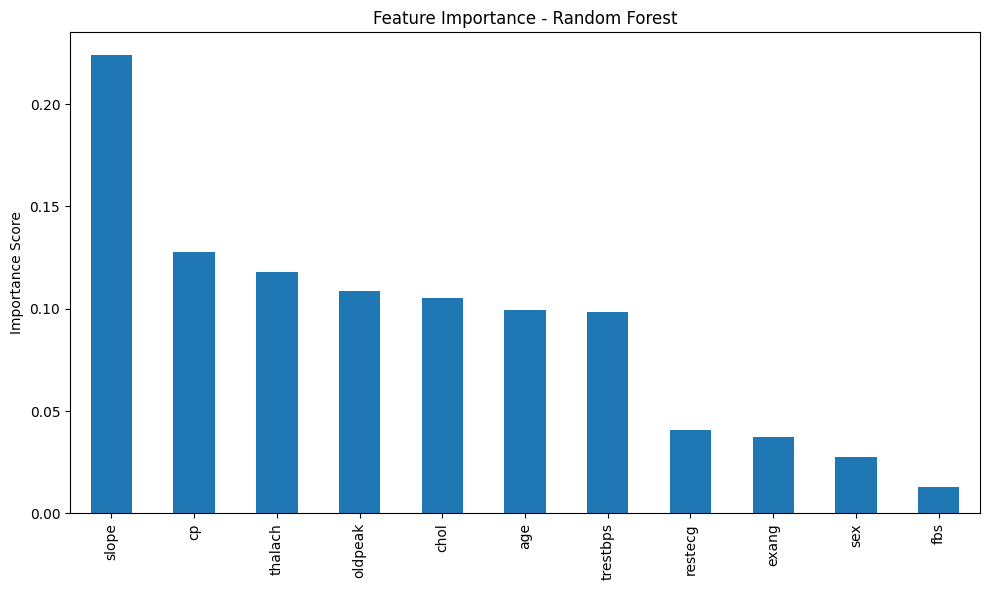

In [38]:
# Visualisasi bar chart
plt.figure(figsize=(10,6))
feat_importances.plot(kind='bar')
plt.title('Feature Importance - Random Forest')
plt.ylabel('Importance Score')
plt.tight_layout()
plt.show()


Model Random Forest mencapai akurasi 83,3% dengan precision, recall, dan f1-score yang seimbang, menunjukkan kemampuan deteksi penyakit jantung yang baik. Kelas "Tidak Sakit Jantung" memiliki precision 87% dan recall 79%, sedangkan kelas "Sakit Jantung" memiliki precision 81% dan recall 88%. Nilai f1-score untuk kedua kelas berada di kisaran 0,83–0,84, mencerminkan performa yang konsisten.

Confusion matrix menunjukkan bahwa model melakukan 7 kesalahan prediksi pada kelas negatif dan 4 kesalahan pada kelas positif, dari total 66 sampel. Evaluasi ini menunjukkan bahwa model mampu meminimalkan false negative, yang sangat penting dalam konteks medis.

## Model 2 Evaluation

In [39]:
y_test_xgb = best_xgb_model.predict(X_test_scaled)

print("=====Result XGBoost=====")
print("Accuracy : ", accuracy_score(y_test,y_test_xgb))
print("====Classification Report====")
target_names = ['Tidak Sakit Jantung', 'Sakit Jantung']
print(classification_report(y_test, y_test_xgb, target_names=target_names))
print("====Conf Matrix====")
print(confusion_matrix(y_test, y_test_xgb))

=====Result XGBoost=====
Accuracy :  0.8484848484848485
====Classification Report====
                     precision    recall  f1-score   support

Tidak Sakit Jantung       0.87      0.82      0.84        33
      Sakit Jantung       0.83      0.88      0.85        33

           accuracy                           0.85        66
          macro avg       0.85      0.85      0.85        66
       weighted avg       0.85      0.85      0.85        66

====Conf Matrix====
[[27  6]
 [ 4 29]]


In [40]:

importances = best_xgb_model.feature_importances_

# Buat DataFrame untuk visualisasi
feature_names = X_train.columns  
feat_importances = pd.Series(importances, index=feature_names)

# Urutkan dari penting ke tidak
feat_importances = feat_importances.sort_values(ascending=False)


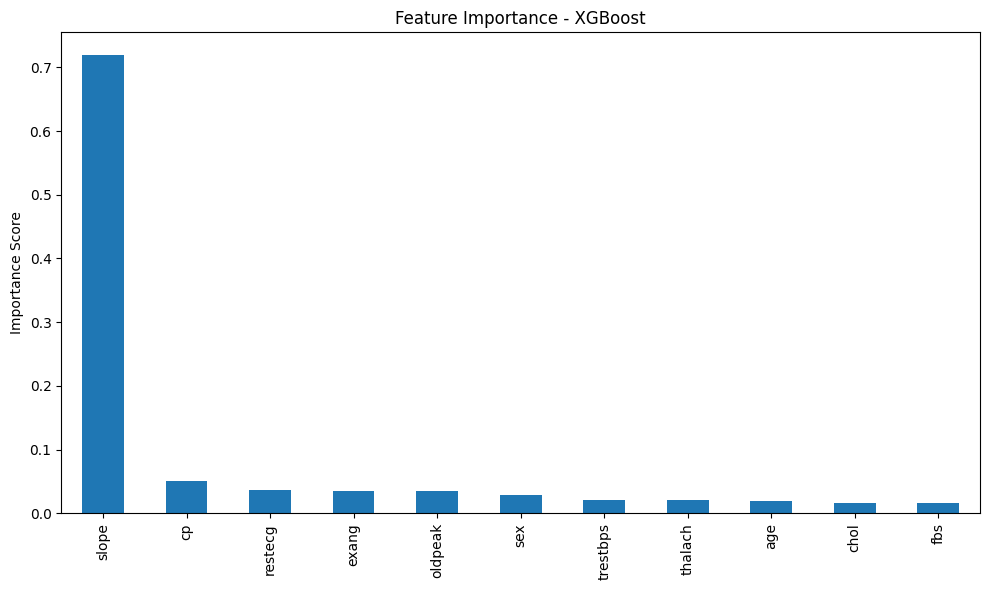

In [41]:
# Visualisasi bar chart
plt.figure(figsize=(10,6))
feat_importances.plot(kind='bar')
plt.title('Feature Importance - XGBoost')
plt.ylabel('Importance Score')
plt.tight_layout()
plt.show()


Model XGBoost berhasil mencapai akurasi 84,8% pada data uji. Precision untuk kelas "Tidak Sakit Jantung" adalah 87% dan untuk "Sakit Jantung" sebesar 83%, sementara recall masing-masing adalah 82% dan 88%. Nilai f1-score untuk kedua kelas masing-masing 0,84 dan 0,85, menunjukkan performa yang seimbang dan andal. Confusion matrix mencatat 6 kesalahan pada kelas negatif dan 4 kesalahan pada kelas positif, dari total 66 sampel.

Dalam proyek ini, dua model dikembangkan: XGBoost dan Random Forest, dengan tuning khusus dilakukan pada Random Forest. Meskipun keduanya menunjukkan performa baik, XGBoost dipilih sebagai model akhir karena memberikan akurasi tertinggi, kemampuan deteksi penyakit jantung yang kuat, serta kesalahan diagnosis yang relatif rendah.

Visualisasi feature importance XGBoost (gambar di bawah) menunjukkan bahwa slope (kemiringan segmen ST) merupakan faktor paling dominan, diikuti oleh cp (tipe nyeri dada) dan exang (angina akibat olahraga):